<a href="https://colab.research.google.com/github/KomalJadhav5602/Dev-sec-ops-eks-infra/blob/main/gold_price_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge

# Time Series Libraries
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prophet
from prophet import Prophet

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ All libraries imported successfully!")
print(f"📊 Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}")

# Corrected code to load the gold price dataset
df = pd.read_csv('gold_prices_10y.csv', parse_dates=['Date'])

# Display basic info
print("\n📊 GOLD PRICE DATASET OVERVIEW")
print("=" * 50)
print(f"\n📅 Date Range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"📈 Total Trading Days: {len(df):,}")
print(f"📊 Number of Features: {len(df.columns)}")

# Display first and last rows
print("\n🔍 First 5 Records:")
display(df.head())

print("\n🔍 Last 5 Records:")
display(df.tail())

✅ All libraries imported successfully!
📊 Analysis Date: 2026-04-07

📊 GOLD PRICE DATASET OVERVIEW

📅 Date Range: 2016-01-29 to 2026-01-23
📈 Total Trading Days: 2,511
📊 Number of Features: 16

🔍 First 5 Records:


,Date,Close,High,Low,Open,Volume,Adj Close,Daily_Return,MA_20,MA_50,MA_200,Volatility_20,Year,Month,Day_of_Week,Quarter
0,2016-01-29,106.95,107.00,106.26,106.61,8098700,106.95,NaN,NaN,NaN,NaN,NaN,2016,1,4,1
1,2016-02-01,108.05,108.15,107.53,107.54,10471800,108.05,1.03,NaN,NaN,NaN,NaN,2016,2,0,1
2,2016-02-02,108.09,108.18,107.35,107.92,6656000,108.09,0.04,NaN,NaN,NaN,NaN,2016,2,1,1
3,2016-02-03,109.25,109.58,107.90,107.91,15785200,109.25,1.07,NaN,NaN,NaN,NaN,2016,2,2,1
4,2016-02-04,110.57,110.70,109.92,110.45,13213700,110.57,1.21,NaN,NaN,NaN,NaN,2016,2,3,1



🔍 Last 5 Records:


,Date,Close,High,Low,Open,Volume,Adj Close,Daily_Return,MA_20,MA_50,MA_200,Volatility_20,Year,Month,Day_of_Week,Quarter
2506,2026-01-16,421.29,424.80,417.04,422.80,20951600,421.29,-0.48,410.59,393.92,339.47,1.48,2026,1,4,1
2507,2026-01-20,437.23,438.14,434.10,436.69,21308100,437.23,3.78,412.52,395.34,340.21,1.67,2026,1,1,1
2508,2026-01-21,443.60,448.00,437.11,446.87,38830200,443.60,1.46,414.75,396.89,341.00,1.68,2026,1,2,1
2509,2026-01-22,451.79,452.98,443.56,443.84,19251200,451.79,1.85,416.93,398.56,341.86,1.66,2026,1,3,1
2510,2026-01-23,458.00,458.75,453.45,454.11,21497000,458.00,1.37,419.15,400.15,342.78,1.66,2026,1,4,1


In [ ]:
from google.colab import files
uploaded_gold_prices_10y = files.upload()

Saving gold_prices_10y.csv to gold_prices_10y.csv


In [ ]:
# Load the gold price dataset
df = pd.read_csv('gold_prices_10y.csv', parse_dates=['Date'])

# Display basic info
print("📊 GOLD PRICE DATASET OVERVIEW")
print("=" * 50)
print(f"\n📅 Date Range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"📈 Total Trading Days: {len(df):,}")
print(f"📊 Number of Features: {len(df.columns)}")

# Display first and last rows
print("\n🔍 First 5 Records:")
display(df.head())

print("\n🔍 Last 5 Records:")
display(df.tail())

📊 GOLD PRICE DATASET OVERVIEW

📅 Date Range: 2016-01-29 to 2026-01-23
📈 Total Trading Days: 2,511
📊 Number of Features: 16

🔍 First 5 Records:


,Date,Close,High,Low,Open,Volume,Adj Close,Daily_Return,MA_20,MA_50,MA_200,Volatility_20,Year,Month,Day_of_Week,Quarter
0,2016-01-29,106.95,107.00,106.26,106.61,8098700,106.95,NaN,NaN,NaN,NaN,NaN,2016,1,4,1
1,2016-02-01,108.05,108.15,107.53,107.54,10471800,108.05,1.03,NaN,NaN,NaN,NaN,2016,2,0,1
2,2016-02-02,108.09,108.18,107.35,107.92,6656000,108.09,0.04,NaN,NaN,NaN,NaN,2016,2,1,1
3,2016-02-03,109.25,109.58,107.90,107.91,15785200,109.25,1.07,NaN,NaN,NaN,NaN,2016,2,2,1
4,2016-02-04,110.57,110.70,109.92,110.45,13213700,110.57,1.21,NaN,NaN,NaN,NaN,2016,2,3,1



🔍 Last 5 Records:


,Date,Close,High,Low,Open,Volume,Adj Close,Daily_Return,MA_20,MA_50,MA_200,Volatility_20,Year,Month,Day_of_Week,Quarter
2506,2026-01-16,421.29,424.80,417.04,422.80,20951600,421.29,-0.48,410.59,393.92,339.47,1.48,2026,1,4,1
2507,2026-01-20,437.23,438.14,434.10,436.69,21308100,437.23,3.78,412.52,395.34,340.21,1.67,2026,1,1,1
2508,2026-01-21,443.60,448.00,437.11,446.87,38830200,443.60,1.46,414.75,396.89,341.00,1.68,2026,1,2,1
2509,2026-01-22,451.79,452.98,443.56,443.84,19251200,451.79,1.85,416.93,398.56,341.86,1.66,2026,1,3,1
2510,2026-01-23,458.00,458.75,453.45,454.11,21497000,458.00,1.37,419.15,400.15,342.78,1.66,2026,1,4,1


In [ ]:
# Dataset Information
print("📋 COLUMN DESCRIPTIONS")
print("=" * 50)
column_descriptions = {
    'Date': 'Trading date',
    'Open': 'Opening price (₹)',
    'High': 'Highest price of the day (₹)',
    'Low': 'Lowest price of the day (₹)',
    'Close': 'Closing price (₹)',
    'Adj Close': 'Adjusted closing price (₹)',
    'Volume': 'Trading volume (shares)',
    'Daily_Return': 'Daily percentage return (%)',
    'MA_20': '20-day moving average (₹)',
    'MA_50': '50-day moving average (₹)',
    'MA_200': '200-day moving average (₹)',
    'Volatility_20': '20-day rolling volatility (%)',
    'Year': 'Calendar year',
    'Month': 'Calendar month (1-12)',
    'Day_of_Week': 'Day of week (0=Monday, 6=Sunday)',
    'Quarter': 'Calendar quarter (1-4)'
}

for col, desc in column_descriptions.items():
    if col in df.columns:
        print(f"  • {col}: {desc}")

📋 COLUMN DESCRIPTIONS
  • Date: Trading date
  • Open: Opening price (₹)
  • High: Highest price of the day (₹)
  • Low: Lowest price of the day (₹)
  • Close: Closing price (₹)
  • Adj Close: Adjusted closing price (₹)
  • Volume: Trading volume (shares)
  • Daily_Return: Daily percentage return (%)
  • MA_20: 20-day moving average (₹)
  • MA_50: 50-day moving average (₹)
  • MA_200: 200-day moving average (₹)
  • Volatility_20: 20-day rolling volatility (%)
  • Year: Calendar year
  • Month: Calendar month (1-12)
  • Day_of_Week: Day of week (0=Monday, 6=Sunday)
  • Quarter: Calendar quarter (1-4)


In [ ]:
# Create Visual Summary Dashboard
fig = make_subplots(
    rows=2, cols=3,
    specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
           [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}]],
    subplot_titles=("", "", "", "", "", "")
)

# Calculate key metrics
current_price = df['Close'].iloc[-1]
start_price = df['Close'].iloc[0]
total_return = ((current_price / start_price) - 1) * 100
avg_daily_volume = df['Volume'].mean()
max_price = df['Close'].max()
avg_volatility = df['Volatility_20'].mean()

# Row 1 Indicators
fig.add_trace(go.Indicator(
    mode="number+delta",
    value=current_price,
    title={"text": "<b>Current Price</b><br><span style='font-size:0.8em;color:gray'>Latest Close</span>"},
    number={"prefix": "₹", "font": {"size": 40, "color": "#FFD700"}},
    delta={"reference": df['Close'].iloc[-20], "relative": True, "valueformat": ".1%"},
    domain={"row": 0, "column": 0}
), row=1, col=1)

fig.add_trace(go.Indicator(
    mode="number",
    value=total_return,
    title={"text": "<b>10-Year Return</b><br><span style='font-size:0.8em;color:gray'>Since 2016</span>"},
    number={"suffix": "%", "font": {"size": 40, "color": "#2ecc71"}},
    domain={"row": 0, "column": 1}
), row=1, col=2)

fig.add_trace(go.Indicator(
    mode="number",
    value=len(df),
    title={"text": "<b>Trading Days</b><br><span style='font-size:0.8em;color:gray'>Total Records</span>"},
    number={"font": {"size": 40, "color": "#3498db"}},
    domain={"row": 0, "column": 2}
), row=1, col=3)

# Row 2 Indicators
fig.add_trace(go.Indicator(
    mode="number",
    value=max_price,
    title={"text": "<b>All-Time High</b><br><span style='font-size:0.8em;color:gray'>Maximum Price</span>"},
    number={"prefix": "₹", "font": {"size": 40, "color": "#e74c3c"}},
    domain={"row": 1, "column": 0}
), row=2, col=1)

fig.add_trace(go.Indicator(
    mode="number",
    value=avg_daily_volume / 1e6,
    title={"text": "<b>Avg Daily Volume</b><br><span style='font-size:0.8em;color:gray'>Million Shares</span>"},
    number={"suffix": "M", "font": {"size": 40, "color": "#9b59b6"}},
    domain={"row": 1, "column": 1}
), row=2, col=2)
fig.add_trace(go.Indicator(
    mode="number",
    value=avg_volatility,
    title={"text": "<b>Avg Volatility</b><br><span style='font-size:0.8em;color:gray'>20-Day Rolling</span>"},
    number={"suffix": "%", "font": {"size": 40, "color": "#f39c12"}},
    domain={"row": 1, "column": 2}
), row=2, col=3)

fig.update_layout(
    height=350,
    template='plotly_dark',
    title_text='<b>📊 Gold Price Key Performance Indicators</b>',
    title_font_size=18,
    paper_bgcolor='rgba(26,26,46,1)',
    plot_bgcolor='rgba(26,26,46,1)'
)
fig.show()

print("\n✅ Dashboard shows key metrics at a glance!")


✅ Dashboard shows key metrics at a glance!


In [ ]:
# Interactive Price Chart with Moving Averages
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    vertical_spacing=0.05,
                    row_heights=[0.7, 0.3],
                    subplot_titles=('Gold Price with Moving Averages', 'Trading Volume'))

# Price with MAs
fig.add_trace(go.Scatter(x=df['Date'], y=df['Close'], name='Close Price',
                         line=dict(color='#FFD700', width=1)), row=1, col=1)
fig.add_trace(go.Scatter(x=df['Date'], y=df['MA_20'], name='MA 20',
                         line=dict(color='#FF6B6B', width=1, dash='dot')), row=1, col=1)
fig.add_trace(go.Scatter(x=df['Date'], y=df['MA_50'], name='MA 50',
                         line=dict(color='#4ECDC4', width=1, dash='dash')), row=1, col=1)
fig.add_trace(go.Scatter(x=df['Date'], y=df['MA_200'], name='MA 200',
                         line=dict(color='#45B7D1', width=2)), row=1, col=1)

# Volume
fig.add_trace(go.Bar(x=df['Date'], y=df['Volume'], name='Volume',
                     marker_color='rgba(100,100,100,0.5)'), row=2, col=1)

fig.update_layout(
    height=700,
    title_text='<b>Gold Price Analysis (2016-2026)</b>',
    title_font_size=20,
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    template='plotly_dark'
)
fig.update_xaxes(title_text="Date", row=2, col=1)
fig.update_yaxes(title_text="Price ($)", row=1, col=1)
fig.update_yaxes(title_text="Volume", row=2, col=1)
fig.show()

In [ ]:
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['Date'], y=df['Daily_Return'],
                         mode='lines', name='Daily Return',
                         line=dict(color='orange')))
fig.update_layout(title='Daily Returns Over Time', template='plotly_dark')
fig.show()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['Date'], y=df['Volatility_20'],
                         mode='lines', name='Volatility',
                         line=dict(color='red')))
fig.update_layout(title='20-Day Rolling Volatility', template='plotly_dark')
fig.show()

In [ ]:
import plotly.express as px

fig = px.histogram(df, x='Close', nbins=50, title='Price Distribution')
fig.update_layout(template='plotly_dark')
fig.show()

In [ ]:
fig = px.box(df, y='Close', title='Box Plot of Gold Prices')
fig.update_layout(template='plotly_dark')
fig.show()

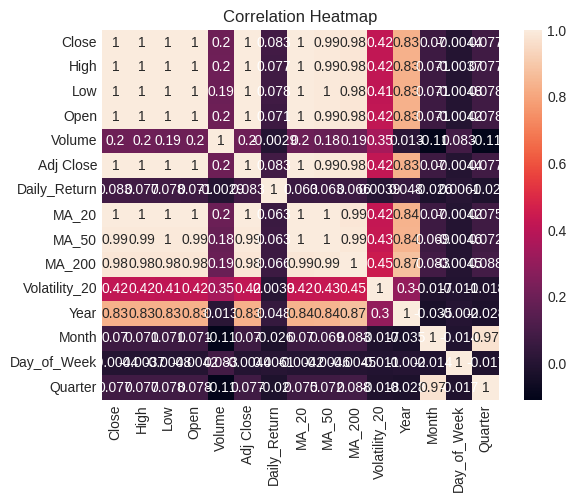

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
fig = px.scatter(df, x='Daily_Return', y='Volatility_20',
                 title='Return vs Volatility')
fig.update_layout(template='plotly_dark')
fig.show()

In [ ]:
yearly = df.groupby('Year')['Close'].mean().reset_index()

fig = px.bar(yearly, x='Year', y='Close',
             title='Year-wise Average Gold Price')
fig.update_layout(template='plotly_dark')
fig.show()

In [ ]:
monthly = df.groupby('Month')['Close'].mean().reset_index()

fig = px.line(monthly, x='Month', y='Close',
              title='Monthly Seasonality')
fig.update_layout(template='plotly_dark')
fig.show()

In [ ]:
df['Rolling_Mean'] = df['Close'].rolling(20).mean()
df['Rolling_Std'] = df['Close'].rolling(20).std()

fig = go.Figure()
fig.add_trace(go.Scatter(x=df['Date'], y=df['Rolling_Mean'], name='Mean'))
fig.add_trace(go.Scatter(x=df['Date'], y=df['Rolling_Std'], name='Std'))
fig.update_layout(title='Rolling Statistics', template='plotly_dark')
fig.show()

In [ ]:
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod()

fig = px.line(df, x='Date', y='Cumulative_Return',
              title='Cumulative Return Growth')
fig.update_layout(template='plotly_dark')
fig.show()

In [ ]:
fig = go.Figure(data=[go.Candlestick(
    x=df['Date'],
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close']
)])
fig.update_layout(title='Candlestick Chart', template='plotly_dark')
fig.show()

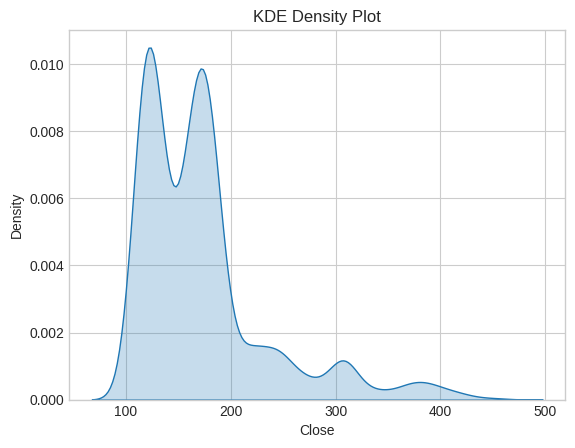

In [ ]:
plt.figure()
sns.kdeplot(df['Close'], fill=True)
plt.title("KDE Density Plot")
plt.show()

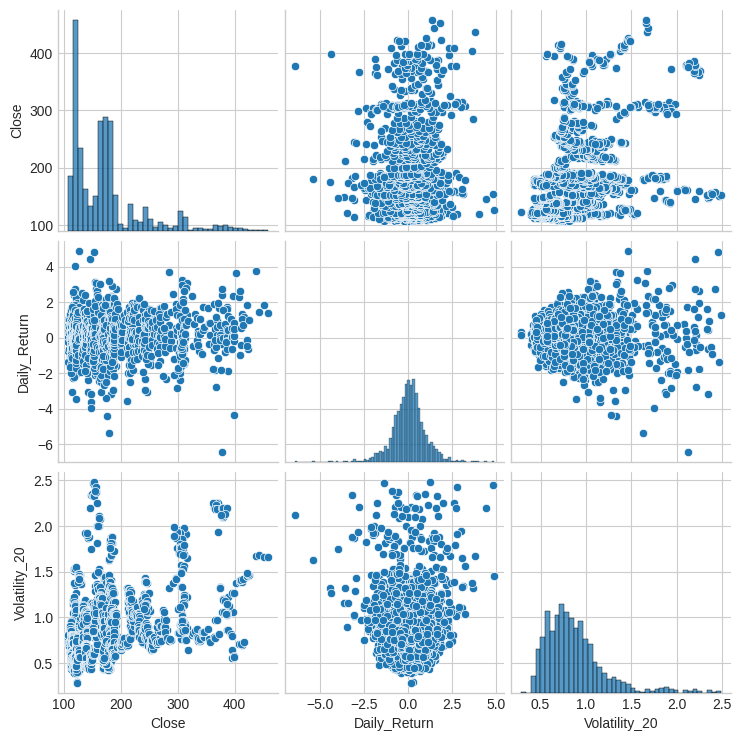

In [ ]:
sns.pairplot(df[['Close', 'Daily_Return', 'Volatility_20']])
plt.show()

In [ ]:
dow = df.groupby('Day_of_Week')['Close'].mean().reset_index()

fig = px.bar(dow, x='Day_of_Week', y='Close',
             title='Day of Week Analysis')
fig.update_layout(template='plotly_dark')
fig.show()

In [ ]:
quarter = df.groupby('Quarter')['Close'].mean().reset_index()

fig = px.bar(quarter, x='Quarter', y='Close',
             title='Quarterly Gold Price Trend')
fig.update_layout(template='plotly_dark')
fig.show()